# Building models for named entity recognition

The project consists in building two named entity recognition (NER) systems. The systems will make use of the IOB tagging scheme to detect entities of type PER, ORG, LOC and MISC. The tagging scheme thus includes the following tags, assuming one tag per token:

- B-PER and I-PER: token corresponds to the start, resp. the inside, of a person's entity
- B-LOC and I-LOC: token corresponds to the start, resp. the inside, of a location entity
- B-ORG and I-ORG: token corresponds to the start, resp. the inside, of an organization entity
- B-MISC and I-MISC: token corresponds to the start, resp. the inside, of any other named entity
- O: token corresponds to no entity

## Dataset

You are provided with training, validation and test data derived from the CONLL 03 dataset. The dataset has been marginally cleaned and reformatted for facilitated use. You can directly load the three folds from the json file provided:

```python
with open('conll03-iob-pos.json', 'r') as f:
    data = json.load(f)
```
For each fold, the dataset consists of a list of dictionaries, one per sample, with the two fields 'tokens' and 'labels', e.g.

{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'tags': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}

## TODO

Building on the notebooks we've seen during the lectures and on the tipcs below, you task is to build two tagging models:
1. a RNN-based model: an embedding layer, a LSTM layer, a feed-forward layer
2. a fine-tuned BERT tagger: a BERT (pre-trained) layer, a feed-forward layer
The final feed-forward layer procudes a probability distribution over the set possible tags for each input token.

For both, we will use BERT's tokenizer, which is a sub-word tokenizer. The advantage of this tokenizer is that the vocabulary is finite (no out-of-vocabulary tokens): you can get the vocabulary size from tokenizer.vocab_size and you don't have to bother with defining your vocabulary and mapping unkown tokens to some special token. The disadvantage of sub-word tokenization is that we will have to relabel the input sequences, which are labeled on a word basis rather than on a sub-word basis. To make things easier, we provide a function that aligns and encode the labels. Note that special tokens will arbitrarily get the tag -100 which is a default value to indicate Torch's loss functions that gradient should not be propagated from there (in other words, ignore thos tokens in training).

Another advantage of using the same tokenizer is that you will have to prepare your dataset and the corresponding loaders only once for the two models.

Here are the steps you'll have to go through:

1. Define a Dataset class that will hold for each sample the list of encoded tokens and the corresponding list of encoded tags. You will then encode the three folds as a Dataset and define the corresponding DataLoader instances.

2. Define your LSTM model class and train it. You can get inspired by the RNN language model notebook.

3. Define your BERT model class and train it. You can adapt the LLM finetuning notebook, changing the classification head to operate on each token (as for the LSTM) rather than on the embedding of the [CLS] token.

4. Evaluate both and compare. Token tag accuracy is one measure (used for instance to measure the convergence of training) but it's not the ultimate one as the final task is not to tag tokens but to detect entities. You should thus also report in the final evaluation the entitu recognition rate.

One last thing to think about: computation of the accuracy for validation and testing must be adapted in two ways compared to what we've seen in the previous notebooks. First, each prediction is a sequence of tags and not a single tag. Second, tags corresponding to the special tokens (indicated as -100 in the reference) must not be accounted for when computing the accuracy (maybe pytorch does that for you but you have to make sure it does).

**Good luck no your mission!**

## REPORT

The report will be a commented notebook. This is not a python programing project but a NLP project. I'm thus expecting you to comment on your model definition choices, to analyze the results and errors, to provide hints at how things could be improved. If you did trial and error cells, please clean up a bit to facilitate reading, leaving only the final version in the report notebook.



In [ ]:
import json
import gzip
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score
import torch
from torch.utils.data import Dataset, DataLoader
import os
import sys, importlib.util
import torch
import torch.nn as nn
from typing import List, Set, Tuple
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# torch verification added
print("python:", sys.executable)
print("torch spec:", importlib.util.find_spec("torch"))

python: /usr/bin/python3
torch spec: ModuleSpec(name='torch', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7e28bfe935c0>, origin='/usr/local/lib/python3.12/dist-packages/torch/__init__.py', submodule_search_locations=['/usr/local/lib/python3.12/dist-packages/torch'])


# Data importation and token-level pre-processing

In this section, we load the dataset and perform the necessary token-level preprocessing required for sequence labeling. In particular, the teacher provided a predefined tag vocabulary. It enables consistent label assignment when words are split into multiple subtokens by the Transformer tokenizer. This design choice facilitates reliable alignment between the original word-level annotations and the resulting subtoken sequence used as model input.

In [ ]:
#
# tag to id mapping and vice versa
#
# for tokens that does not have a tag, we will use -100 as the corresponding tag ID
#

tag2id = {
    'O': 0,
    'B-LOC': 1, 'I-LOC': 2,
    'B-ORG': 3, 'I-ORG': 4,
    'B-PER': 5, 'I-PER': 6,
    'B-MISC': 7, 'I-MISC': 8
}

id2tag = list(tag2id.keys())

print(tag2id)

{'O': 0, 'B-LOC': 1, 'I-LOC': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-PER': 5, 'I-PER': 6, 'B-MISC': 7, 'I-MISC': 8}


In [ ]:
#
# load data from json file
# Don't forget to put your own path

with gzip.open('/content/sample_data/conll03-iob-pos.json.gz', 'r') as f:
    data = json.load(f)

for fold in ('train', 'valid', 'test'):
    print(fold, len(data[fold]))

print(data['train'][0])

train 14041
valid 3250
test 3453
{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'tags': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}


## Tokenizer, alignment and encoding

In [ ]:
#
# load BERT's tokenizer -- this
#

checkpoint = 'distilbert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
print(tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

BertTokenizer(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


I used this cell to further explore the BERT tokenizer in order to better understand its outputs (notably `input_ids`, `attention_mask`, and the word-to-subtoken alignment). This preliminary inspection proved useful for implementing the dataset classes later on, as it clarified how original word-level annotations should be aligned with the subtokenized sequences used for model training and evaluation.

In [ ]:
print(tokenizer("dog")) #added
print(tokenizer("cat"))
print(tokenizer('Ismael'))
print(tokenizer('Daouda'))
print(tokenizer('AI'))
print(tokenizer("machine learning"))

{'input_ids': [101, 3676, 102], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}
{'input_ids': [101, 5855, 102], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}
{'input_ids': [101, 2181, 1918, 1883, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}
{'input_ids': [101, 10136, 13431, 1161, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}
{'input_ids': [101, 19016, 102], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}
{'input_ids': [101, 3395, 3776, 102], 'token_type_ids': [0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1]}


In [ ]:
# added
# Here's an example showing how to tokenize texts and create the corresponding aligned and encoded labels
#
# Note that the tokenizer enables to retrieve the index of the corresponding wordform for each (sub-word) token
# through the inputs.word_ids(batch_index=i) function (to retrieve input word indices for each token in
# inputs['input_ids'][i]). Special tokens ([CLS], [SEP], [PAD]) are mapped to None. We will make use of this
# mapping to create token-level labels adapted to sub-word tokenization. See next cell.
#

train_texts = [x['tokens'] for x in data['train']]
train_labels = [x['tags'] for x in data['train']]

inputs = tokenizer(train_texts, is_split_into_words=True, padding=True, truncation=True, return_tensors="pt")

print(train_texts[0])
print(train_labels[0])
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))
print(inputs.word_ids(batch_index=0))

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']
['[CLS]', 'EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'la', '##mb', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]

The `align_and_encode_labels()` function enables label alignment at the subtoken level by mapping each original word-level tag to the corresponding subword tokens produced by the tokenizer. I kept this implementation as provided by the instructor.

While an alternative approach is to assign a special ignore label (e.g., `-100`) to all subtokens beyond the first subtoken of each word, I instead propagate the word’s label to its subtokens. This choice avoids discarding potentially useful information introduced by subword segmentation and ensures that all subtokens contribute to the training signal.


In [ ]:
def align_and_encode_labels(_token_ids, _word_ids, _labels):
    '''
    Align word-level labels to sub-word tokens for an entry
    '''

    global tag2id

    ignore_id = -100

    buf = [ignore_id] # ignore tag for token [CLS] essentially start of sentence token

    prev_token_word = -1
    which_type = 0

    # print(len(_token_ids), tokenizer.convert_ids_to_tokens(_token_ids))
    # print(_word_ids)
    # print(_labels)

    for i in range(1, len(_token_ids)):
        word_id = _word_ids[i]

        if word_id == None:
            # token does not belong to any input word ([CLS], [SEP] or [PAD]) -- ignore
            buf.append(ignore_id)

        else:
            tag_id = tag2id[_labels[word_id]]

            if word_id == prev_token_word:
            # sub-word token of the previous word: need to do something
            #   word has an O tag: just use a O tag
            #   word has an I-X tag: just use the I-X tag
            #   word has a B-X tag: replace by corresponding I-X tag

                buf.append(tag_id + 1 if tag_id in (1, 3, 5, 7) else tag_id) #the design class has been taken in a good way

            else:
                # token starting a new word --> keep tag unchanged
                prev_token_word = word_id
                buf.append(tag_id)

    return buf

In [ ]:
#
# The following illustrate how we can get aligned and encoded labels for sample i in the training set.
#

i = 10

print(train_texts[i], train_labels[i])

new_labels = align_and_encode_labels(inputs['input_ids'][i], inputs.word_ids(batch_index=i), train_labels[i])
print(inputs['input_ids'][i].shape)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][i])

for j in range(len(tokens)):
    if tokens[j] != '[PAD]':
        print(tokens[j], ' -- ', id2tag[new_labels[j]] if new_labels[j] >= 0 else 'NONE')

['Spanish', 'Farm', 'Minister', 'Loyola', 'de', 'Palacio', 'had', 'earlier', 'accused', 'Fischler', 'at', 'an', 'EU', 'farm', 'ministers', "'", 'meeting', 'of', 'causing', 'unjustified', 'alarm', 'through', '"', 'dangerous', 'generalisation', '.', '"'] ['B-MISC', 'O', 'O', 'B-PER', 'I-PER', 'I-PER', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
torch.Size([173])
[CLS]  --  NONE
Spanish  --  B-MISC
Farm  --  O
Minister  --  O
Loyola  --  B-PER
de  --  I-PER
Pa  --  I-PER
##la  --  I-PER
##cio  --  I-PER
had  --  O
earlier  --  O
accused  --  O
Fi  --  B-PER
##sch  --  I-PER
##ler  --  I-PER
at  --  O
an  --  O
EU  --  B-ORG
farm  --  O
ministers  --  O
'  --  O
meeting  --  O
of  --  O
causing  --  O
un  --  O
##ju  --  O
##st  --  O
##ified  --  O
alarm  --  O
through  --  O
"  --  O
dangerous  --  O
general  --  O
##isation  --  O
.  --  O
"  --  O
[SEP]  --  NONE


## Creation of the dataset class

I define a custom `Dataset` to interface the tokenized inputs with PyTorch’s `DataLoader`. The class stores the standard components required for supervised token classification—namely the **token encodings** (`input_ids`) and their **subtoken-aligned labels**—which are used during both training and evaluation.

In addition, the dataset provides three masking vectors that are leveraged during evaluation and model forwarding:

- **Mask 1 (token-level evaluation mask).**  
  This mask excludes positions that should not contribute to token-level metrics, including: subword continuations, special tokens (e.g., `[CLS]`, `[SEP]`), padding tokens, and tokens associated with the neutral/background class (typically the *O* tag). The objective is to reduce the effect of class imbalance and to focus token-level evaluation on informative positions.

- **Mask 2 (entity-focused evaluation mask).**  
  This mask is less restrictive: it excludes only a subset of the categories removed by Mask 1 (specifically, special tokens and padding). It is used to assess performance under a stricter entity-oriented criterion, i.e., whether the model predicts coherent entity structures when all relevant subtokens are included.

- **Mask (Transformer attention mask).**  
  This is the standard `attention_mask` produced by the tokenizer (1 for non-padding tokens, 0 for padding). It is passed to the BERT encoder to ensure self-attention does not attend to padded positions.

The motivation for introducing these masks is to compute evaluation metrics under different inclusion criteria (token-level vs entity-oriented evaluation) while ensuring correct Transformer behaviour via the attention mask. The detailed usage of these masks is described in the evaluation section.

Overall, this dataset class is directly compatible with `DataLoader` and can be used without additional wrappers.



In [ ]:
# The notebook already provided good alignment, using a tokenizer
# Let's define a clean class for our dataset and load them correctly

class MyDataset(Dataset):
    def __init__(self, encodings, labels, mask1, mask2, attention_mask):

        assert(len(encodings) == len(labels))

        self.nsamples = len(labels)

        print(f'Initializing dataset with {self.nsamples} entries')

        self.encodings = encodings # list[list[int]]: contains the padded list of token ids for each sample
        self.labels = labels # list[int]: contains the label for each sample
        self.nlabels = len(set([lab for seq in labels for lab in seq if lab >= 0])) # int: number of labels in the dataset

        self.mask1 = mask1
        self.mask2 = mask2
        self.attention_mask = attention_mask

    def __getitem__(self, idx):
        '''
        Returns a dictionary containing the label and padded token ids for a sample
        '''

        # print(f'accessing dataset item at index {idx}')
        # print(torch.tensor(self.encodings[idx]), torch.tensor(self.labels[idx]))

        return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
         "mask1": torch.tensor(self.mask1[idx]), "mask2": torch.tensor(self.mask2[idx]),
         "mask": torch.tensor(self.attention_mask[idx])}

    def __len__(self):
        return len(self.labels)

In the cell below, we compute and organize all dataset-related quantities. For clarity, each variable is systematically suffixed with `train`, `valid`, or `test` to indicate the corresponding split.

- **`texts_*`**: raw input utterances.
- **`x_labels_*`**: original word-level labels prior to subtoken alignment.
- **`inputs_*`**: tokenized outputs produced by the Transformer tokenizer, including subword segmentation and padding (e.g., `input_ids`, `attention_mask`, and optionally `special_tokens_mask`).
- **`label_input_set_*`**: paired structure containing both the tokenized inputs and the corresponding (unaligned) labels, used as an intermediate object for alignment.
- **`labels_*`**: aligned subtoken-level labels obtained by matching the word-level annotations to the tokenized representation.
- **`encodings_*`**: the token IDs extracted from `inputs_*` (i.e., `input_ids`).
- **`word_ids_*`**: word-to-subtoken indices returned by the tokenizer, used to trace which subtokens originate from the same word; combined with `special_tokens_mask` to identify special tokens.
- **`mask1_*` and `mask2_*`**: evaluation masks computed via a dedicated helper function, as described previously.
- **`mask_*`**: the BERT **attention mask** provided by the tokenizer, indicating which positions correspond to real tokens (1) versus padding (0); this is passed to the encoder during forward propagation.

We implemented a dedicated helper function to generate the two evaluation masks introduced above. The resulting vectors are stored as `mask1` and `mask2` and are subsequently used during evaluation to compute metrics under different inclusion criteria.



In [ ]:
# In this cell, we are trying to formalize our new labels and the token encodings
# This will permit us via the above data class to put things in a good shape and ease the training part

def mask_function(wid, inputs, option = True): #the option permit to choose mask 1 or two
    vec = []
    for i in range(len(wid)):
        vec1 = []
        words_id = wid[i]
        inputs_id = inputs[i]
        for j in range(len(words_id)):
            if words_id[j] == None:
                vec1.append(0)
            else:
                if ((words_id[j] == words_id[j-1]) | (inputs_id.special_tokens_mask[j] == 1)):
                    vec1.append(0)
                else:
                    value = 1
                    if option:
                        if words_id[j] == 0:
                            value = 0
                    vec1.append(value)
        vec.append(vec1)

    return vec

In [ ]:
train_texts, test_texts, valid_texts = [[x['tokens'] for x in data[y]] for y in ["train","test","valid"]]
train_labels, test_labels, valid_labels = [[x['tags'] for x in data[y]] for y in ["train","test","valid"]] #native labels
labels_set = [train_labels, test_labels, valid_labels]

inputs_train, inputs_test, inputs_valid = [tokenizer(x, is_split_into_words=True, padding=True, truncation=True, return_tensors="pt")
                                           for x in [train_texts, test_texts, valid_texts]]
inputs_set = [inputs_train, inputs_test, inputs_valid]

label_input_set = [[inputs_train, train_labels], [inputs_test, test_labels], [inputs_valid, valid_labels]]

encodings_train, encodings_test, encodings_valid = [x['input_ids'] for x in [inputs_train, inputs_test, inputs_valid]]

word_ids_train, word_ids_test, word_ids_valid = [[x.word_ids(batch_index = i) for i in range(len(x['input_ids']))] for x in [inputs_train, inputs_test, inputs_valid]]

labels_train, labels_test, labels_valid = [[align_and_encode_labels(
                                                                    x[0]['input_ids'][i],
                                                                    x[0].word_ids(batch_index=i),
                                                                    x[1][i])
                                                                    for i in range(len(x[0]['input_ids']))]
                                                                             for x in label_input_set]


mask1_train, mask1_valid, mask1_test = [mask_function(word_ids_train, inputs_train), mask_function(word_ids_valid, inputs_valid), mask_function(word_ids_test, inputs_test)]
mask2_train, mask2_valid, mask2_test = [mask_function(word_ids_train, inputs_train, False), mask_function(word_ids_valid, inputs_valid, False), mask_function(word_ids_test, inputs_test, False)]

mask_train = inputs_train["attention_mask"]
mask_valid = inputs_valid["attention_mask"]
mask_test  = inputs_test["attention_mask"]

At this stage, we simply instantiate the dataset by providing the essential components (encodings, aligned labels, and the associated masks). The resulting object is directly compatible with a PyTorch `DataLoader`, and can therefore be used seamlessly for model training and evaluation.

In [ ]:
data_ready = dict()

data_ready['train'] = MyDataset(encodings_train, labels_train, mask1_train, mask2_train, mask_train)
data_ready['test'] = MyDataset(encodings_test, labels_test, mask1_test, mask2_test, mask_test)
data_ready['valid'] = MyDataset(encodings_valid, labels_valid, mask1_valid, mask2_valid, mask_valid)

Initializing dataset with 14041 entries
Initializing dataset with 3453 entries
Initializing dataset with 3250 entries


In [ ]:
# you could play with this cell to understand each elements for the following
i = 58
print("dataset_class", data_ready['train'][i])
print("raw text",train_texts[i])
print("ids for alignment", word_ids_train[i])
#print(labels_train[i])
print("attention mask", inputs_train[0].attention_mask)
inputs_train[i]

dataset_class {'ids': tensor([  101,  3460,  2110,  7176,  1116, 14159,  9084,  1548,  1110,  1280,
         1106,  1294,  1126,  2078,  8679,  1170,   170,  6109,  2309,  1224,
         1113,  9170,   117,  1163,   156,  8752,  6919,  2386,  1548,   119,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,

/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}


Encoding(num_tokens=173, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])

# Model settings

## RNN_tagger architecture

The RNN-based tagger is composed of the following modules:

- **Embedding layer.**  
  A trainable embedding layer maps each input token ID to a dense vector representation of dimension `embed_dim`.

- **Bi-directional LSTM encoder.**  
  A bi-directional LSTM is used to model contextual dependencies in both left-to-right and right-to-left directions. The hidden size (`hidden_dim`) is treated as a tunable hyperparameter. The bi-directional setting allows the model to incorporate both preceding and following context for each token.

- **Feed-forward classification head.**  
  The LSTM outputs are fed to a feed-forward network applied at each time step:
  - a linear layer projecting from the LSTM output dimension to an intermediate dimension (`ff_dim`),
  - a non-linear activation (ReLU),
  - a dropout layer for regularization,
  - a final linear layer mapping to `num_labels`, producing per-token logits (converted to probabilities via softmax during inference).

- Dropout is applied within the feed-forward head as a tunable regularization mechanism.  
  For the recurrent component, PyTorch applies LSTM dropout **only when `num_layers > 1`**; consequently, when using a single LSTM layer, recurrent dropout is effectively disabled. If multiple LSTM layers are used, the same dropout rate is applied between LSTM layers.


In [ ]:
class RNN_tagger(torch.nn.Module):

    def __init__(self, vocsize, num_labels = len(id2tag), embed_dim = 200, hidden_dim = 256,
                num_layers = 1, dropout = 0.1 , ff_dim = 256, bi = True):
        super().__init__()

        self.embedding = nn.Embedding(num_embeddings = vocsize,
                                      embedding_dim = embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim//2,
            num_layers=num_layers,
            batch_first=True,
            dropout = min((num_layers-1), 1)* dropout,
            bidirectional = bi
        )


        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, num_labels),
        )

        self.nclasses = num_labels

    def forward(self, ids):

        x = self.embedding(ids)
        x, _ = self.lstm(x)
        logits = self.ff(x)
        return logits

## BERT-tagger architecture

We use the following architecture for the BERT-based tagger.

- **Pre-trained Transformer encoder (DistilBERT/BERT).**  
  A checkpoint such as `distilbert-base-cased` is used as the backbone encoder. Given an input sequence of token IDs, the encoder outputs a contextual representation for each token. Since the experiments are conducted on a small GPU provided by Google Collab, DistilBERT is preferred for computational efficiency: it is substantially faster than BERT while retaining most of its representational capacity as reported in the original distillation work.

- **Token-level classification head (feed-forward network).**  
  On top of the encoder, we apply a lightweight feed-forward head independently at each token position:
  1. A linear projection from the encoder hidden size to an intermediate dimension `ff_dim`.
  2. A non-linear activation (ReLU).
  3. A dropout layer for regularization (tuned during experiments).
  4. A final linear layer mapping to `num_labels`, producing per-token logits over the tag set (converted to probabilities via softmax during inference).

- **Attention masking.**  
  The `attention_mask` is passed to the encoder so that self-attention ignores padding tokens and attends only to valid tokens.

This architecture leverages the Transformer’s self-attention to model bidirectional context, and replaces the recurrent layer used in the LSTM baseline with a pre-trained contextual encoder.


In [ ]:
class Bert_tagger(nn.Module):

    def __init__(
        self, model_name = "distilbert-base-cased", num_labels = len(id2tag), dropout= 0.1,
        ff_dim = 128, freeze_bert= False):

        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.ff = nn.Sequential(
            nn.Linear(hidden_size, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, num_labels),
        )

        self.nclasses = num_labels

        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

    def forward(self, ids, mask=None):

        out = self.bert(input_ids=ids, attention_mask=mask)
        x = out.last_hidden_state
        logits = self.ff(x)
        return logits


## Training and validation functions

To streamline experimentation across multiple architectures, we implemented a set of reusable training and evaluation utilities. These functions are designed to be model-agnostic and therefore compatible with both the recurrent baseline and the Transformer-based tagger.

In particular, the `train_step` function takes as inputs a model, a data loader, an optimizer, and a loss function. For each mini-batch, it performs the standard training operations (forward pass, loss computation, backpropagation, and parameter update), accumulates the training loss over the epoch, and returns the total (or aggregated) loss.  

This design allows us to interchange optimizers and loss functions without modifying the training loop, facilitating consistent comparisons across models and hyperparameter settings.

In [ ]:
def train_step(_model, _loader, _loss, _optim, device="cpu", report=0, bert_use = False):

    _model.train(True)
    total_loss = 0.
    running_loss = 0.

    for i, batch in enumerate(_loader):
        _optim.zero_grad()

        labels = batch['label'].to(device)

        set_for_the_lstm = {'label', 'mask1','mask2', 'mask'}
        set_for_the_bert = {'label', 'mask1','mask2'}

        if bert_use:
            set_for_the_forward = set_for_the_bert
        else:
            set_for_the_forward = set_for_the_lstm

        inputs = {k: v.to(device) for k, v in batch.items() if k not in set_for_the_forward}
        outputs = _model(**inputs)

        loss = _loss(outputs.permute(0, 2, 1), labels)

        total_loss += loss.item()
        running_loss += loss.item()

        loss.backward()
        _optim.step()

        if report != 0 and i % report == report - 1:
            print('  batch {} avg. loss per batch={:.4f}'.format(i + 1, running_loss / report))
            running_loss = 0.

    _model.train(False)

    return total_loss

## Validation and evaluation procedure

The validation pipeline is intentionally more elaborate than the training step, as it is used for **model selection** and therefore requires multiple complementary metrics.

### Design choice: loss vs masked metrics
During training, I compute the **cross-entropy loss** on the full token sequence (using the standard ignore index for padded/irrelevant positions), without applying additional evaluation masks. In contrast, several of the evaluation metrics are computed under **masking schemes**.  
This separation was adopted for practical reasons: some metrics (especially span-based evaluation) are non-trivial to implement and integrating them directly into the training objective would substantially complicate the training loop. Consequently, the loss remains the sole optimization target, while masked metrics are used exclusively for **hyperparameter tuning and model comparison**.

### Metrics computed on the validation set
I report two families of validation metrics:

1. **Token-level accuracy, micro-F1, and macro-F1 (subtoken-aware).**  
   These metrics evaluate token-wise classification quality. To mitigate the impact of class imbalance, I pay particular attention to **macro-F1**, which weights classes more evenly than micro-F1/accuracy. In addition, for these token-level metrics I exclude the neutral/background class (label `0`, typically corresponding to the *O* tag) in order to focus evaluation on informative labeled tokens.

2. **Span-level F1 (F1-span).**  
   Span-level evaluation is the most informative for NER because it measures whether complete entities are recovered correctly, including boundary consistency. To compute spans from BIO predictions, I follow an approach consistent with the `seqeval` library (e.g., the `bio_to_spans` conversion strategy used by chakki-works).  
   Reference implementation: `seqeval` (chakki-works), BIO-to-span conversion.  
   https://github.com/chakki-works/seqeval?tab=readme-ov-file

3. **`ner_metrics`.**  
   This function takes the model outputs and the corresponding gold span representations, converts predictions into span sequences, and computes the metric suite described above.

4. **`eval_step`**  
   This procedure aggregates all components of the evaluation workflow (loss computation, token-level metrics, and span-level metrics) and returns the full set of validation statistics.

### Experimental workflow
At this stage, the overall workflow consists of:
- building the datasets and corresponding dataloaders,
- performing hyperparameter search via grid exploration,
- training models using `train_step`,
- selecting the best configuration based on the validation metrics (with particular emphasis on **F1-span**).

The general structure of the training, validation, and testing routines follows the templates introduced during the deep learning practical sessions, with extensions to support span-level NER evaluation.


In [ ]:
def bio_to_spans(tags):
    """
    Convert a BIO tag sequence into a set of entity spans.
    Span format: (start_idx, end_idx_exclusive, entity_type)
    """
    spans = set()
    start, ent_type = None, None

    def close_entity(end):
        nonlocal start, ent_type
        if start is not None:
            spans.add((start, end, ent_type))
            start, ent_type = None, None

    for i, tag in enumerate(tags):
        if tag == "O" or tag is None:
            close_entity(i)
            continue

        if "-" not in tag:
            close_entity(i)
            continue

        prefix, typ = tag.split("-", 1)

        if prefix == "B":
            close_entity(i)
            start, ent_type = i, typ

        elif prefix == "I":
            if start is None or ent_type != typ:
                close_entity(i)
                start, ent_type = i, typ
            # else continue

        else:
            close_entity(i)

    close_entity(len(tags))
    return spans

In [ ]:
def ner_metrics(logits, labels, mask1, mask2):

    preds = logits.argmax(dim=-1)  # (N, T)
    mask1 = mask1.bool()
    mask2 = mask2.bool()

    y_true = labels[mask1].detach().cpu().numpy()
    y_pred = preds[mask1].detach().cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1_micro = f1_score(y_true, y_pred, average="micro")
    f1_macro = f1_score(y_true, y_pred, average="macro")

    TP = FP = FN = 0

    N = labels.size(0)
    for i in range(N):
        pred_tags = [id2tag[int(pid)] for pid in preds[i][mask2[i]]]
        gold_tags = [id2tag[int(lid)] for lid in labels[i][mask2[i]]]

        pred_spans = bio_to_spans(pred_tags)
        gold_spans = bio_to_spans(gold_tags)

        TP += len(pred_spans & gold_spans)
        FP += len(pred_spans - gold_spans)
        FN += len(gold_spans - pred_spans)

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1_span        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return acc, f1_micro, f1_macro, f1_span

In [ ]:
def eval_step(_model, _loader, device='cpu', loss_fn=None, bert_use = False):
    '''
    Evaluate the model's performance on data within loader.

    :return:
    total_loss accumulated throughout the batches
    accuracy
    '''

    # logger.debug('running eval_acc_recprec() on %s', device)

    _model.eval()
    total_loss = 0.0

    all_logits = []
    all_labels = []
    all_masks1 = []
    all_masks2 = []

    set_for_the_lstm = {'label', 'mask1','mask2', 'mask'}
    set_for_the_bert = {'label', 'mask1','mask2'}

    if bert_use:
        set_for_the_forward = set_for_the_bert
    else:
        set_for_the_forward = set_for_the_lstm

    with torch.no_grad():
        for batch in _loader:
            batch_labels = batch["label"].to(device)        # (B, T)
            batch_mask1 = batch["mask1"].to(device)
            batch_mask2 = batch["mask2"].to(device)


            inputs = {k: v.to(device) for k, v in batch.items()
                      if k not in set_for_the_forward}

            outputs = _model(**inputs)                        # (B, T, C)

            all_logits.append(outputs.detach().cpu())
            all_labels.append(batch_labels.detach().cpu())
            all_masks1.append(batch_mask1.detach().cpu())
            all_masks2.append(batch_mask2.detach().cpu())

            if loss_fn is not None:
                B, T, C = outputs.shape
                loss = loss_fn(outputs.view(-1, C), batch_labels.view(-1))
                total_loss += loss.item()

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    mask1   = torch.cat(all_masks1, dim=0)
    mask2   = torch.cat(all_masks2, dim=0)

    acc, f1_micro, f1_macro, f1_span = ner_metrics(logits, labels, mask1, mask2)

    return total_loss, acc, f1_micro, f1_macro, f1_span

## BiLSTM training

We use only the CPU for the BiLSTM, as it is the less complex of the two models used in this notebook. Given the limited resources of Colab, we preferred to use the GPU for the second model, which is more complex

For the first hyperparameter tuning round, we restricted the search to a small set of key hyperparameters:
- the **learning rate**,
- the **hidden dimension** (and associated intermediate feed-forward dimension),
- and the **dropout rate**.

To limit computational cost, we fixed the **batch size to 32** and used a bounded number of DataLoader workers. On more powerful hardware, both the batch size and the number of workers could be increased to improve throughput.


In [ ]:
# hyperparameter and params
nw = min(10, os.cpu_count()) # my machine is about 22 cores

nepochs = 7
device = "cpu"
report_freq = 200

batch_size = [32] # be aware of your RAM when running it
lr = [1e-2, 1e-3] #
hidden_dim = [256, 128] # also used for ff_dim
dropout = [0.10, 0.15, 0.25]

For this first round, let's not do early stopping for now and go through the 7 epochs.

In [ ]:
results = []
for bs in batch_size:
    for lra in lr:
        for hd in hidden_dim:
            for do in dropout:

                # Model and data loading

                model = RNN_tagger(vocsize = tokenizer.vocab_size, hidden_dim = hd, dropout = do , ff_dim = hd)
                loader = dict()
                loader['train'] = DataLoader(data_ready['train'], batch_size=bs, shuffle=True, num_workers = nw, persistent_workers=True, prefetch_factor=2) # set to False for debugging purposes
                loader['valid'] = DataLoader(data_ready['valid'], batch_size=bs, shuffle=True, num_workers = nw, persistent_workers=True, prefetch_factor=2)
                optimizer = torch.optim.AdamW(model.parameters(), lr=lra)
                model.to(device)
                celoss = torch.nn.CrossEntropyLoss(ignore_index=-100)

                # Training

                for epoch in range(nepochs):
                    print(f'epoch: {epoch}')

                    total_loss = train_step(model, loader['train'], celoss, optimizer, device=device, report=report_freq)
                    total_loss_val, acc, f1_micro, f1_macro, f1_span = eval_step(model, loader['valid'], device=device, loss_fn=celoss)
                    print('  **valid** f1 macro={:.4f}    span f1={:.2f}%'.format(f1_macro, f1_span))


                results.append({
                    "batch_size": bs,
                    "lr": lra,
                    "hidden_dim": hd,
                    "dropout": do,
                    "train_loss": float(total_loss),
                    "val_loss": float(total_loss_val),
                    "acc": float(acc),
                    "f1_micro": float(f1_micro),
                    "f1_macro": float(f1_macro),
                    "f1_span": float(f1_span)
                })
                print(results)

epoch: 0


/tmp/ipython-input-11-2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-11-2837883649.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipython-input-11-2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-11-2837883649.py:31: UserWarning: To 

  batch 200 avg. loss per batch=0.4241
  batch 400 avg. loss per batch=0.2166


/tmp/ipython-input-11-2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-11-2837883649.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipython-input-11-2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-11-2837883649.py:31: UserWarning: To 

  **valid** f1 macro=0.7712    span f1=0.73%
epoch: 1


In [ ]:
df_results_lstm_round1 = pd.DataFrame(results)
df_results_lstm_round1 = df_results_lstm_round1[['batch_size','lr','hidden_dim','dropout','train_loss','val_loss','acc','f1_micro','f1_macro','f1_span']]

df_results_lstm_round1.sort_values("f1_span", ascending=False)

,batch_size,lr,hidden_dim,dropout,train_loss,val_loss,acc,f1_micro,f1_macro,f1_span
3,32,0.010,128,0.25,19.590833,29.477993,0.963232,0.963232,0.816641,0.780585
0,32,0.010,256,0.15,20.432074,31.573636,0.962733,0.962733,0.809619,0.774618
4,32,0.001,256,0.15,2.600990,32.092293,0.962463,0.962463,0.812392,0.774129
5,32,0.001,256,0.25,3.417200,33.257838,0.961735,0.961735,0.815897,0.771155
1,32,0.010,256,0.25,21.090196,32.173967,0.962296,0.962296,0.805024,0.769722
7,32,0.001,128,0.25,5.130441,33.398689,0.957848,0.957848,0.790619,0.762873
2,32,0.010,128,0.15,17.196972,28.473806,0.961028,0.961028,0.792095,0.760124
6,32,0.001,128,0.15,5.126811,34.708549,0.957370,0.957370,0.791586,0.754445


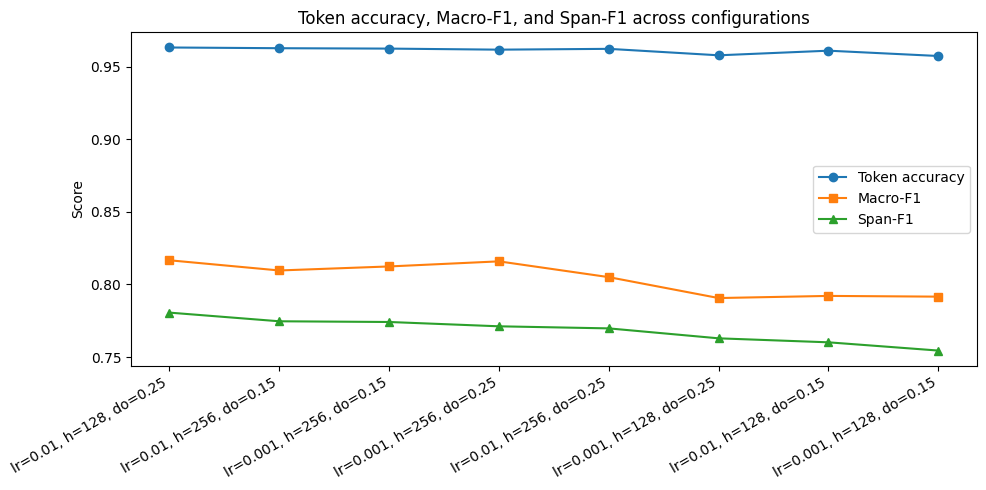

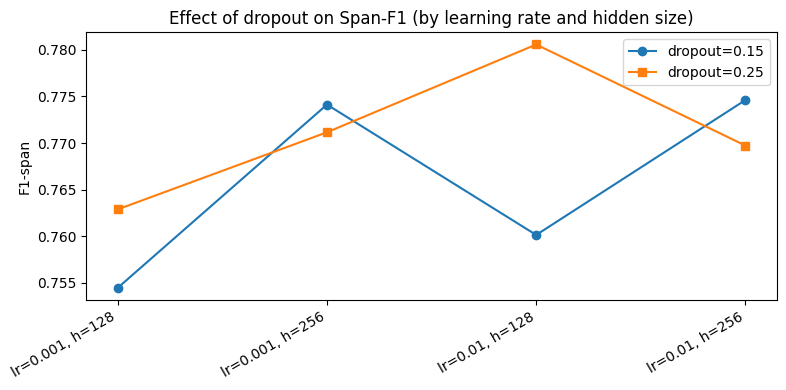

In [ ]:

df_results_lstm_round1["config"] = df_results_lstm_round1.apply(
    lambda r: f"lr={r['lr']}, h={int(r['hidden_dim'])}, do={r['dropout']}", axis=1
)
df_sorted = df_results_lstm_round1.sort_values("f1_span", ascending=False).reset_index(drop=True)

# --- Figure 2: Token accuracy vs Macro-F1 vs Span-F1 ---
plt.figure(figsize=(10,5))
plt.plot(df_sorted["config"], df_sorted["acc"], marker="o", label="Token accuracy")
plt.plot(df_sorted["config"], df_sorted["f1_macro"], marker="s", label="Macro-F1")
plt.plot(df_sorted["config"], df_sorted["f1_span"], marker="^", label="Span-F1")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Token accuracy, Macro-F1, and Span-F1 across configurations")
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 3: Dropout effect on Span-F1 (grouped by lr and hidden_dim) ---
pivot = df_results_lstm_round1.pivot_table(
    index=["lr", "hidden_dim"], columns="dropout", values="f1_span"
).sort_index()

plt.figure(figsize=(8,4))
xlabels = [f"lr={lr}, h={h}" for (lr, h) in pivot.index]
x = range(len(xlabels))

plt.plot(x, pivot.get(0.15), marker="o", label="dropout=0.15")
plt.plot(x, pivot.get(0.25), marker="s", label="dropout=0.25")
plt.xticks(list(x), xlabels, rotation=30, ha="right")
plt.ylabel("F1-span")
plt.title("Effect of dropout on Span-F1 (by learning rate and hidden size)")
plt.legend()
plt.tight_layout()
plt.show()


## Hyperparameter study (BiLSTM NER)

We evaluated eight configurations while keeping the batch size fixed (32) and varying the learning rate (1e-3 vs 1e-2), the LSTM hidden dimension (128 vs 256), and dropout (0.15 vs 0.25) as showed previously. Model selection is discussed primarily with respect to **token-level accuracy**, **macro-F1**, and **span-level F1 (F1-span)**, as span-level evaluation better reflects real entity performance in NER.

The strongest configuration is **lr = 0.01, hidden_dim = 128, dropout = 0.25**, achieving the highest **token accuracy (0.9632)**, **macro-F1 (0.8166)**, and **F1-span (0.7806)**. This indicates that the same setting improves both token classification and full entity extraction quality.  Across runs, **lr = 0.01** yields consistently stronger **F1-span** than **lr = 0.001**. This suggests that, given the current training schedule, a larger step size is beneficial for learning entity boundary patterns rather than remaining in a slower optimization regime. Increasing the hidden dimension from **128 to 256** does not improve span-level performance in this experiment. In fact, the best span-F1 is obtained with **hidden_dim = 128**, suggesting that additional capacity does not translate into better generalization.

Based on the above, we retain **(lr=0.01, hidden_dim=128, dropout=0.25)** as the primary candidate for subsequent experiments and ablations, using **F1-span** as the main selection criterion and macro-F1 as a complementary indicator of performance on minority classes. But we will try 4 more models with early stopping playing with learning rate and dropout while the others stayed the same in the best config. The early stoping has a tolerance delta and a number of 2 steps to let the model redress before stopping. We will take the best config for the test and final scores.

In [ ]:
batch_size = [32]
lr = [1e-2, 2e-2] #
hidden_dim = [128] # also used for ff_dim
dropout = [0.25, 0.3]

In [ ]:
results = []
patience = 2
min_delta = 1e-4

models = []

for bs in batch_size:
    for lra in lr:
        for hd in hidden_dim:
            for do in dropout:

                # Model and data loading

                model = RNN_tagger(vocsize = tokenizer.vocab_size, hidden_dim = hd, dropout = do , ff_dim = hd)
                loader = dict()
                loader['train'] = DataLoader(data_ready['train'], batch_size=bs, shuffle=True, num_workers = nw, persistent_workers=True, prefetch_factor=2) # set to False for debugging purposes
                loader['valid'] = DataLoader(data_ready['valid'], batch_size=bs, shuffle=True, num_workers = nw, persistent_workers=True, prefetch_factor=2)
                loader['test'] = DataLoader(data_ready['test'], batch_size=bs, shuffle=True, num_workers = nw, persistent_workers=True, prefetch_factor=2)
                optimizer = torch.optim.AdamW(model.parameters(), lr=lra)
                model.to(device)
                celoss = torch.nn.CrossEntropyLoss(ignore_index=-100)

                best_f1_span = -float("inf")
                best_epoch = -1
                best_metrics = None
                bad_epochs = 0

                # Training

                for epoch in range(nepochs):
                    print(f'epoch: {epoch}')

                    total_loss = train_step(model, loader['train'], celoss, optimizer, device=device, report=report_freq)
                    total_loss_val, acc, f1_micro, f1_macro, f1_span = eval_step(model, loader['valid'], device=device, loss_fn=celoss)
                    total_loss_test, acc_test, f1_micro_test, f1_macro_test, f1_span_test = eval_step(model, loader['test'], device=device, loss_fn=celoss)
                    print('  **valid** f1 macro={:.4f}    span f1={:.2f}%'.format(f1_macro, f1_span))

                    if f1_span > best_f1_span + min_delta:
                        best_f1_span = f1_span
                        best_f1_span_test = f1_span_test
                        best_epoch = epoch
                        best_acc = acc
                        bad_epochs = 0
                        total_best_loss = total_loss
                        total_best_val_loss = total_loss_val
                    else:
                        bad_epochs += 1
                        if bad_epochs >= patience:
                            print(f"Early stopping at epoch {epoch} (best epoch {best_epoch}, best f1_span={best_f1_span:.4f})")
                            break



                results.append({
                    "batch_size": bs,
                    "lr": lra,
                    "hidden_dim": hd,
                    "dropout": do,
                    "train_loss": float(total_best_loss),
                    "val_loss": float(total_best_val_loss),
                    "best_acc": float(best_acc),
                    "best_f1_span": best_f1_span,
                    "bepoch": best_epoch,
                    "span_test": best_f1_span_test
                })
                print(results)

epoch: 0


/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy con

  batch 200 avg. loss per batch=0.4734
  batch 400 avg. loss per batch=0.2303


/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324

  **valid** f1 macro=0.7688    span f1=0.71%
epoch: 1
  batch 200 avg. loss per batch=0.1244
  batch 400 avg. loss per batch=0.1221
  **valid** f1 macro=0.7876    span f1=0.76%
epoch: 2
  batch 200 avg. loss per batch=0.0682
  batch 400 avg. loss per batch=0.0854
  **valid** f1 macro=0.8014    span f1=0.77%
epoch: 3
  batch 200 avg. loss per batch=0.0517
  batch 400 avg. loss per batch=0.0623
  **valid** f1 macro=0.7906    span f1=0.76%
epoch: 4
  batch 200 avg. loss per batch=0.0457
  batch 400 avg. loss per batch=0.0570
  **valid** f1 macro=0.8026    span f1=0.76%
Early stopping at epoch 4 (best epoch 2, best f1_span=0.7656)
[{'batch_size': 32, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.25, 'train_loss': 34.64905830845237, 'val_loss': 23.931426588445902, 'best_acc': 0.9613817758563352, 'best_f1_span': 0.7656380316930774, 'bepoch': 2, 'span_test': 0.6871015631822549}]
epoch: 0


...

  **valid** f1 macro=0.7209    span f1=0.66%
epoch: 1
  batch 200 avg. loss per batch=0.1839
  batch 400 avg. loss per batch=0.1937
  **valid** f1 macro=0.7419    span f1=0.70%
epoch: 2
  batch 200 avg. loss per batch=0.1519
  batch 400 avg. loss per batch=0.1666
  **valid** f1 macro=0.7652    span f1=0.73%
epoch: 3
  batch 200 avg. loss per batch=0.1311
  batch 400 avg. loss per batch=0.1461
  **valid** f1 macro=0.7757    span f1=0.73%
epoch: 4
  batch 200 avg. loss per batch=0.1209
  batch 400 avg. loss per batch=0.1361
  **valid** f1 macro=0.7773    span f1=0.74%
epoch: 5
  batch 200 avg. loss per batch=0.1098
  batch 400 avg. loss per batch=0.1288
  **valid** f1 macro=0.7661    span f1=0.72%
epoch: 6
  batch 200 avg. loss per batch=0.1141
  batch 400 avg. loss per batch=0.1283
  **valid** f1 macro=0.7761    span f1=0.73%
Early stopping at epoch 6 (best epoch 4, best f1_span=0.7357)
[{'batch_size': 32, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.25, 'train_loss': 34.64905830845237, 

/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324

  batch 200 avg. loss per batch=0.4921
  batch 400 avg. loss per batch=0.2801


/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipykernel_8324/3722364746.py:29: UserWarning: To copy con

  **valid** f1 macro=0.7298    span f1=0.67%
epoch: 1
  batch 200 avg. loss per batch=0.1853
  batch 400 avg. loss per batch=0.2026
  **valid** f1 macro=0.7487    span f1=0.70%
epoch: 2
  batch 200 avg. loss per batch=0.1509
  batch 400 avg. loss per batch=0.1669
  **valid** f1 macro=0.7622    span f1=0.72%
epoch: 3
  batch 200 avg. loss per batch=0.1347
  batch 400 avg. loss per batch=0.1499
  **valid** f1 macro=0.7727    span f1=0.74%
epoch: 4
  batch 200 avg. loss per batch=0.1290
  batch 400 avg. loss per batch=0.1420
  **valid** f1 macro=0.7753    span f1=0.73%
epoch: 5
  batch 200 avg. loss per batch=0.1134
  batch 400 avg. loss per batch=0.1390
  **valid** f1 macro=0.7873    span f1=0.75%
epoch: 6
  batch 200 avg. loss per batch=0.1170
  batch 400 avg. loss per batch=0.1326
  **valid** f1 macro=0.7718    span f1=0.73%
[{'batch_size': 32, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.25, 'train_loss': 34.64905830845237, 'val_loss': 23.931426588445902, 'best_acc': 0.9613817758563352

In [ ]:
df_results_lstm_round2 = pd.DataFrame(results)
df_results_lstm_round2.sort_values("best_f1_span", ascending=False)

,batch_size,lr,hidden_dim,dropout,train_loss,val_loss,best_acc,best_f1_span,bepoch,span_test
1,32,0.01,128,0.30,23.158792,28.931030,0.964396,0.787641,4,0.703155
0,32,0.01,128,0.25,34.649058,23.931427,0.961382,0.765638,2,0.687102
3,32,0.02,128,0.30,55.916973,29.802993,0.958992,0.747917,5,0.674967
2,32,0.02,128,0.25,56.761572,27.992631,0.956871,0.735726,4,0.650100


The results of the second tuning round suggest that increasing dropout from **0.25 to 0.30** yields, at best, a **marginal improvement** in span-level performance: the highest observed **best F1-span** is **0.7876** (dropout=0.30, lr=0.01), compared to **0.6871** (dropout=0.25, lr=0.01). However, this improvement is achieved at **epoch 4**, whereas the configuration with dropout=0.25 reaches a nearly identical score earlier (**epoch 2**). From an efficiency perspective, the 0.25 setting provides comparable performance with fewer training epochs.

In contrast, increasing the learning rate to **0.02** degrades span-level performance substantially (best F1-span ≈ 0.73–0.74), indicating that this step size is too aggressive for the BiLSTM baseline under the current training setup.

Overall, we retain **(lr = 0.01, hidden_dim = 128, dropout = 0.25)** as the final configuration for the BiLSTM model, as it offers the best trade-off between validation performance and training efficiency.  
We now proceed to fine-tune **DistilBERT** using a single, fixed set of hyperparameters.


In [ ]:
f1_span_final = 0.687102
print("The f1-span of the final model on the test set is:", f1_span_final)

The f1-span of the final model is: 0.687102


In retrospect, the BiLSTM baseline gave me a solid and interpretable starting point, but it also highlighted clear limitations for NER. Even though token-level accuracy and micro-F1 are high, the difference with F1-span suggests that the model still makes boundary and consistency errors when reconstructing full entities, which is precisely what matters most in NER. This is also consistent with the class imbalance of the task, so I relied more on macro-F1 and span-level evaluation rather than accuracy alone. During my tuning rounds, I observed that the model is quite sensitive to optimization and regularization: lr = 0.02 noticeably degraded span performance, while lr = 0.01 remained stable, and increasing dropout from 0.25 to 0.30 only brought a marginal improvement that required more epochs to reach, so I retained (lr=0.01, hidden_dim=128, dropout=0.25) as the best trade-off between performance and efficiency. These results suggest several concrete directions for improvement on the recurrent approach, such as adding a CRF decoding layer to enforce valid BIO transitions, using stronger regularization or imbalance-aware objectives, and selecting the stopping point directly with span-level metrics (early stopping on F1-span). Overall, this baseline justified moving to a fine-tuned Transformer (DistilBERT), which should better capture long-range dependencies and improve span-level consistency under the same evaluation protocol.

## DistilBERT Training

For DistilBERT, I performed a structured hyperparameter search rather than a single run. The experiments vary:

- **Batch size**
- **Encoder learning rate (`lr_bert`)**
- **Classification head learning rate (`lr_ff`)**
- **Dropout**

For each configuration, a new `Bert_tagger` model is instantiated and fully fine-tuned (`freeze_bert = False`). Both the pre-trained DistilBERT encoder and the task-specific feed-forward head are updated during training.

I use **differential learning rates** through parameter groups in `AdamW`:
- A **small learning rate for the encoder** (`lr_bert`) to carefully adapt the pretrained contextual representations without disrupting their general linguistic knowledge.
- A **separate learning rate for the classification head** (`lr_ff`), which is randomly initialized and therefore requires stronger updates to learn the NER mapping.

Weight decay (0.01) is applied following the original BERT training recommendations.

For each configuration, I train for a fixed number of epochs and evaluate on both validation and test sets after every epoch. The collected metrics include:

- Validation loss  
- Token accuracy  
- Micro-F1  
- Macro-F1  
- Span-level F1 (F1-span)  
- Test F1-span  

All results are stored in `results_bert`, allowing systematic comparison across configurations. Model selection is primarily driven by **F1-span**, as it better reflects real entity extraction quality compared to token-level metrics.


In [ ]:
torch.cuda.is_available()

True

In [ ]:
# hyperparameter and params
nw = min(12, os.cpu_count())

nepochs = 5
device = "cuda" if torch.cuda.is_available() else "cpu"
report_freq = 200

batch_size1 = [32, 64]
lrff1 = [1e-2, 1e-3]
lrbert1 = [1e-5, 3e-5]
hidden_dim = 128
dropout1 = [0.3]
freeze = False

In [ ]:
results_bert = []

for batch_size in batch_size1:
  for lrff in lrff1:
    for lrbert in lrbert1:
      for dropout in dropout1:

        model_bert_f = Bert_tagger(num_labels = len(id2tag), dropout= dropout, ff_dim = hidden_dim, freeze_bert= freeze)
        loader = dict()
        loader['train'] = DataLoader(data_ready['train'], batch_size=batch_size, shuffle=True, num_workers = nw, persistent_workers=True, prefetch_factor=2) # set to False for debugging purposes
        loader['valid'] = DataLoader(data_ready['valid'], batch_size=batch_size, shuffle=False, num_workers = nw, persistent_workers=True, prefetch_factor=2)
        loader['test'] = DataLoader(data_ready['test'], batch_size=batch_size, shuffle=False, num_workers = nw, persistent_workers=True, prefetch_factor=2)
        optimizer = torch.optim.AdamW( [ {"params": model_bert_f.bert.parameters(), "lr": lrbert},
                                        {"params": model_bert_f.ff.parameters(), "lr": lrff}, ],
                                        weight_decay=0.01 ) # decay as in the Jacob Devlin paper
        model_bert_f.to(device)
        celoss = torch.nn.CrossEntropyLoss(ignore_index=-100)

        # Training

        for epoch in range(nepochs):
            print(f'epoch: {epoch}')

            total_loss = train_step(model_bert_f, loader['train'], celoss, optimizer, device=device, report=report_freq, bert_use = True)
            total_loss_val, acc, f1_micro, f1_macro, f1_span = eval_step(model_bert_f, loader['valid'], device=device, loss_fn=celoss, bert_use = True)
            total_loss_test, acc_test, f1_micro_test, f1_macro_test, f1_span_test = eval_step(model_bert_f, loader['test'], device=device, loss_fn=celoss, bert_use = True)

            print('  **valid** f1 macro={:.4f}    span f1={:.2f}%'.format(f1_macro, f1_span))


        results_bert.append(
        {
            "batch_size": batch_size,
            "lr_bert": lrbert,
            "lr_ff": lrff,
            "ff_dim": hidden_dim,
            "dropout": dropout,
            "freeze_bert": freeze,
            "train_loss": float(total_loss),
            "val_loss": float(total_loss_val),
            "acc": float(acc),
            "f1_micro": float(f1_micro),
            "f1_macro": float(f1_macro),
            "f1_span": float(f1_span),
            "f1_span_test": float(f1_span_test)
        }
        )

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


epoch: 0


/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarn

...

epoch: 0


/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarn

  batch 200 avg. loss per batch=0.2655


/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "mask": torch.tensor(self.attention_mask[idx])}
/tmp/ipython-input-1604/2837883649.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {'ids': torch.tensor(self.encodings[idx]), 'label': torch.tensor(self.labels[idx]),
/tmp/ipython-input-1604/2837883649.py:31: UserWarn

  **valid** f1 macro=0.8973    span f1=0.90%
epoch: 1
  batch 200 avg. loss per batch=0.0728
  **valid** f1 macro=0.9188    span f1=0.92%
epoch: 2
  batch 200 avg. loss per batch=0.0425
  **valid** f1 macro=0.9316    span f1=0.93%
epoch: 3
  batch 200 avg. loss per batch=0.0274
  **valid** f1 macro=0.9401    span f1=0.94%
epoch: 4
  batch 200 avg. loss per batch=0.0180
  **valid** f1 macro=0.9347    span f1=0.93%


In [ ]:
df_results_bert = pd.DataFrame(results_bert)
df_results_bert.to_csv("/content/sample_data/results.csv", index=False)

In [ ]:
df = df_results_bert.copy()
df

,batch_size,lr_bert,lr_ff,ff_dim,dropout,freeze_bert,train_loss,val_loss,acc,f1_micro,f1_macro,f1_span,f1_span_test
0,32,0.00001,0.010,128,0.3,False,17.357362,9.500363,0.988340,0.988340,0.932880,0.927842,0.890840
1,32,0.00003,0.010,128,0.3,False,10.006576,11.119741,0.988402,0.988402,0.929695,0.931205,0.886753
2,32,0.00001,0.001,128,0.3,False,11.742342,7.240377,0.988589,0.988589,0.931896,0.928983,0.881447
3,32,0.00003,0.001,128,0.3,False,6.839393,8.264923,0.989254,0.989254,0.937862,0.932065,0.892147
4,64,0.00001,0.010,128,0.3,False,9.619786,4.258820,0.987695,0.987695,0.924631,0.921140,0.879002
5,64,0.00003,0.010,128,0.3,False,4.892037,4.931182,0.989026,0.989026,0.933988,0.930832,0.888850
6,64,0.00001,0.001,128,0.3,False,8.329453,4.011218,0.987446,0.987446,0.925519,0.921948,0.878049
7,64,0.00003,0.001,128,0.3,False,3.993726,3.697842,0.989400,0.989400,0.934702,0.934863,0.892146


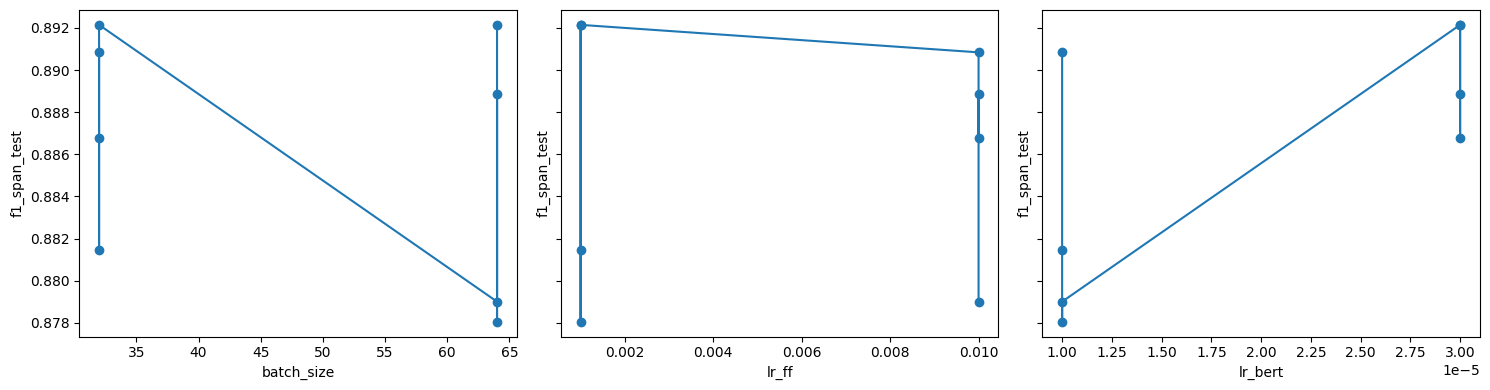

In [ ]:
df_sorted = df.sort_values(by=["batch_size", "lr_ff", "lr_bert"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, xcol in zip(axes, ["batch_size", "lr_ff", "lr_bert"]):
    df_sorted = df.sort_values(by=[xcol])
    ax.plot(df_sorted[xcol], df_sorted["f1_span_test"], marker="o")
    ax.set_xlabel(xcol)
    ax.set_ylabel("f1_span_test")

plt.tight_layout()
plt.show()

We evaluated eight DistilBERT configurations by varying the batch size (32 vs 64), the encoder learning rate (1e-5 vs 3e-5), and the feed-forward learning rate (1e-3 vs 1e-2), while keeping the feed-forward dimension (128), dropout (0.3), and full fine-tuning setting (freeze_bert=False) constant. Model selection is discussed primarily with respect to token-level accuracy, macro-F1, and span-level F1 (F1-span), with particular emphasis on F1-span, as entity-level evaluation better reflects real NER performance than token metrics alone.

The strongest configuration is batch_size = 64, lr_bert = 3e-5, lr_ff = 1e-3, achieving the highest validation accuracy (0.9894), macro-F1 (0.9347), and F1-span (0.9349). It also reaches one of the best test F1-span scores (0.8921), confirming that this setting generalizes well beyond validation data. This indicates that moderately increasing the encoder learning rate to 3e-5 improves boundary learning and entity consistency without destabilizing fine-tuning.

Across runs, lr_bert = 3e-5 consistently outperforms 1e-5 in terms of F1-span, suggesting that the smaller step size may under-adapt the pretrained representations to the NER task under the current training schedule. Regarding the task-specific head, lr_ff = 1e-3 appears more stable than 1e-2, especially when combined with the higher encoder learning rate, leading to better validation and test span-level performance. This suggests that an excessively large learning rate in the classification head may introduce unnecessary variance without improving generalization.

Increasing the batch size from 32 to 64 generally improves stability and slightly boosts span-level metrics, likely due to smoother gradient estimates during fine-tuning. Importantly, token-level accuracy remains uniformly high across configurations (~0.988–0.989), reinforcing that span-level metrics provide better discrimination between strong and average models.

Based on these results, we retain (batch_size=64, lr_bert=3e-5, lr_ff=1e-3, ff_dim=128, dropout=0.3, freeze_bert=False) as the primary candidate for subsequent experiments and final evaluation. Model selection is driven primarily by F1-span, with macro-F1 serving as a complementary indicator of robustness across entity classes.